In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline

In [56]:
df = pd.read_csv("data/survey_results_public.csv", low_memory=False)

In [57]:
pd.set_option('display.max_columns', 172)
pd.set_option('display.max_rows', 139)

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), str(119)
memory usage: 64.6 MB


In [59]:
df = df[
    (df['WorkExp'] >= 0) &
    (df['WorkExp'] <= 40) &          
    (df['CompTotal'] > 0) &
    (df['CompTotal'] <= 300000)      
]
df = df[['WorkExp', 'CompTotal']].dropna()
df.tail()

,WorkExp,CompTotal
49177,9.0,17000.0
49178,20.0,75000.0
49179,5.0,180000.0
49180,1.0,70000.0
49188,17.0,80000.0


In [60]:
x = df[['WorkExp']]
y = df[['CompTotal']]
x.info()
y.info()

<class 'pandas.DataFrame'>
Index: 18205 entries, 0 to 49188
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   WorkExp  18205 non-null  float64
dtypes: float64(1)
memory usage: 284.5 KB
<class 'pandas.DataFrame'>
Index: 18205 entries, 0 to 49188
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CompTotal  18205 non-null  float64
dtypes: float64(1)
memory usage: 284.5 KB


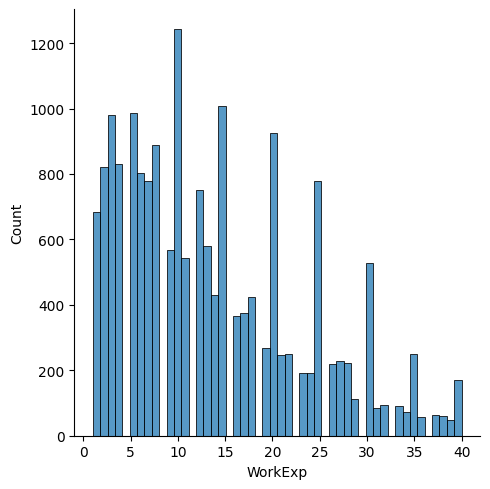

In [61]:
sns.displot(df["WorkExp"], kde=False, bins=50)

<Axes: xlabel='count', ylabel='WorkExp'>

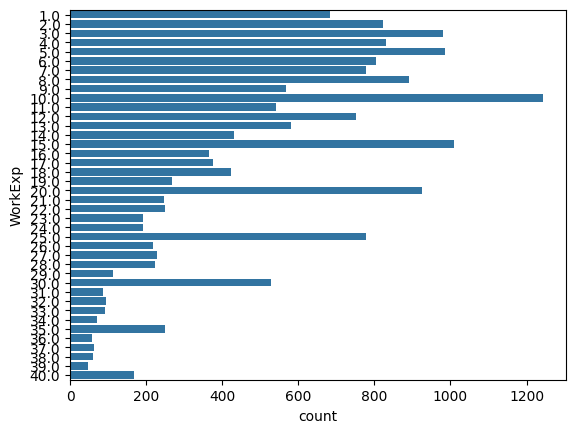

In [62]:
sns.countplot(y='WorkExp', data=df)

<Axes: xlabel='WorkExp', ylabel='CompTotal'>

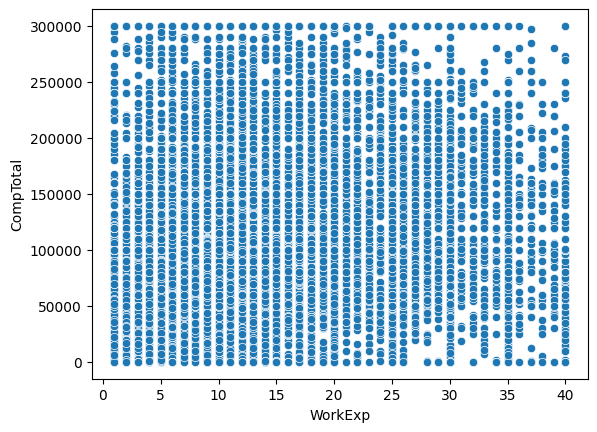

In [64]:
sns.scatterplot(x='WorkExp', y='CompTotal', data=df)

<Axes: >

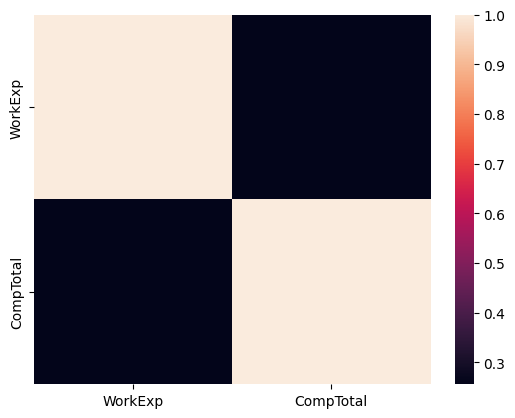

In [65]:
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr())

In [66]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 1/3, random_state = 0)

In [67]:
# Fitting Simple Linear Regression to the Training Set
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [68]:
# Predicting the Test set resutlt
y_pred = lr.predict(x_test)
y_pred

array([[ 84500.47106598],
       [ 84500.47106598],
       [131162.4779706 ],
       ...,
       [ 78901.03023743],
       [118097.1160373 ],
       [ 90099.91189453]], shape=(6069, 1))

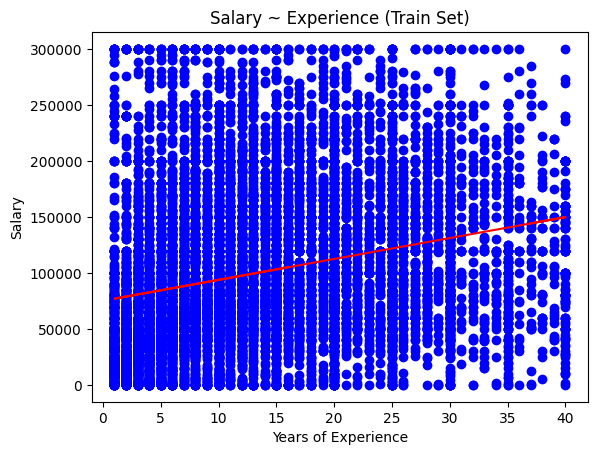

In [69]:
# Visualise the training set results
plt.scatter(x_train, y_train, color='blue')
plt.plot(x_train, lr.predict(x_train), color='red')
plt.title('Salary ~ Experience (Train Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

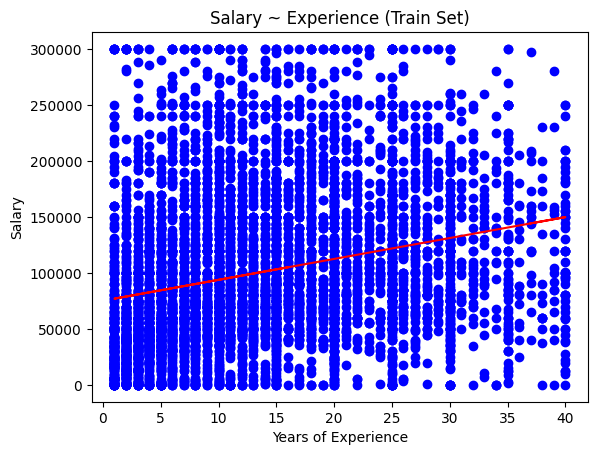

In [70]:
plt.scatter(x_test, y_test, color = 'blue')
plt.plot(x_train, lr.predict(x_train), color='red')
plt.title('Salary ~ Experience (Train Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [73]:
# Calculating the residules
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:',np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('RMSE:',np.sqrt(metrics.mean_absolute_error(y_test, y_pred)))

MAE: 52835.83236034661
MSE: 4482883338.041258
RMSE: 66954.3377089286
RMSE: 229.86046280373364


In [72]:
from sklearn.metrics import r2_score

print(r2_score(y_test, y_pred))

0.06192634295828581
